In [7]:
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

In [3]:
df = yf.download("CAD=X", start="2007-01-01", end="2012-12-31")
df.columns = df.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2007-01-01,1.1643,1.1664,1.1608,1.1660,0
2007-01-02,1.1648,1.1657,1.1625,1.1645,0
2007-01-03,1.1726,1.1735,1.1637,1.1646,0
2007-01-04,1.1776,1.1777,1.1713,1.1725,0
2007-01-05,1.1738,1.1785,1.1716,1.1775,0


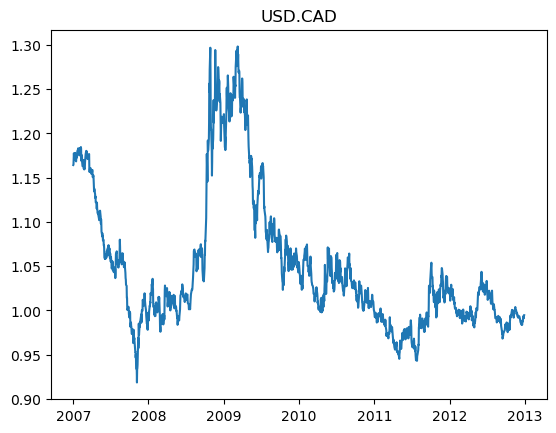

In [11]:
plt.plot( df["Close"])
plt.title("USD.CAD")
plt.show()

In [12]:
close = df["Close"].dropna()
close.head()

Date
2007-01-01    1.1643
2007-01-02    1.1648
2007-01-03    1.1726
2007-01-04    1.1776
2007-01-05    1.1738
Name: Close, dtype: float64

In [13]:
result_k0 = adfuller(close, maxlag=0, regression="c")

In [14]:
print(f"ADF statistic: {result_k0[0]:.4f}")
print(f"p-value: {result_k0[1]:.4f}")
print(f"lags used: {result_k0[2]}")
print(f"n observations: {result_k0[3]}")
print(f"critical values: {result_k0[4]}")

ADF statistic: -2.1929
p-value: 0.2088
lags used: 0
n observations: 1556
critical values: {'1%': np.float64(-3.4345595891554566), '5%': np.float64(-2.863399278674411), '10%': np.float64(-2.5677598491451947)}


- adfuller tests H0: the series has a unit root (i.e., it's a random walk — non-stationary, no tendency to revert to a mean). H1: the series is stationary (mean-reverting).
- regression='c' — include a constant (nonzero mean/offset, since USD/CAD's long-run average is nowhere near zero) but no linear time-trend term (since we're not assuming price systematically drifts up or down over time, just fluctuates around some level).
- maxlag=0 — the simplest version of the test, no lagged difference terms included to account for serial correlation in the price changes themselves.
- The ADF statistic — a more negative number is more evidence against the unit root (more evidence of stationarity/mean-reversion). Compare it against the critical values dict: if your statistic is more negative than the critical value at (say) the 5% level, you reject H0 — evidence of stationarity.
- The p-value — same logic as always: small p (< 0.05 conventionally) → reject H0 → evidence of stationarity. Large p → fail to reject → looks like a random walk.

In [20]:
result_k1 = adfuller(close, maxlag=1, regression="c", autolag=None)

print(f"ADF statistic: {result_k1[0]:.4f}")
print(f"p-value: {result_k1[1]:.4f}")
print(f"lags used: {result_k1[2]}")
print(f"n observations: {result_k1[3]}")
print(f"critical values: {result_k1[4]}")

ADF statistic: -2.1920
p-value: 0.2091
lags used: 1
n observations: 1555
critical values: {'1%': np.float64(-3.4345623007753496), '5%': np.float64(-2.8634004754910296), '10%': np.float64(-2.567760486450719)}


**conclusion for both tests**
- H0: USD/CAD (2007–2012) has a unit root (non-stationary/random walk).
- H1: USD/CAD is stationary (mean-reverting).
- k=0: fail to reject (p=0.209). k=1: fail to reject (p=0.209). No evidence of mean-reversion in this window at either lag.